In [2]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print(df.shape)
df.head().T

(569, 31)


,0,1,2,3,4
mean radius,17.990000,20.570000,19.690000,11.420000,20.290000
mean texture,10.380000,17.770000,21.250000,20.380000,14.340000
mean perimeter,122.800000,132.900000,130.000000,77.580000,135.100000
mean area,1001.000000,1326.000000,1203.000000,386.100000,1297.000000
mean smoothness,0.118400,0.084740,0.109600,0.142500,0.100300
mean compactness,0.277600,0.078640,0.159900,0.283900,0.132800
mean concavity,0.300100,0.086900,0.197400,0.241400,0.198000
mean concave points,0.147100,0.070170,0.127900,0.105200,0.104300
mean symmetry,0.241900,0.181200,0.206900,0.259700,0.180900
mean fractal dimension,0.078710,0.056670,0.059990,0.097440,0.058830


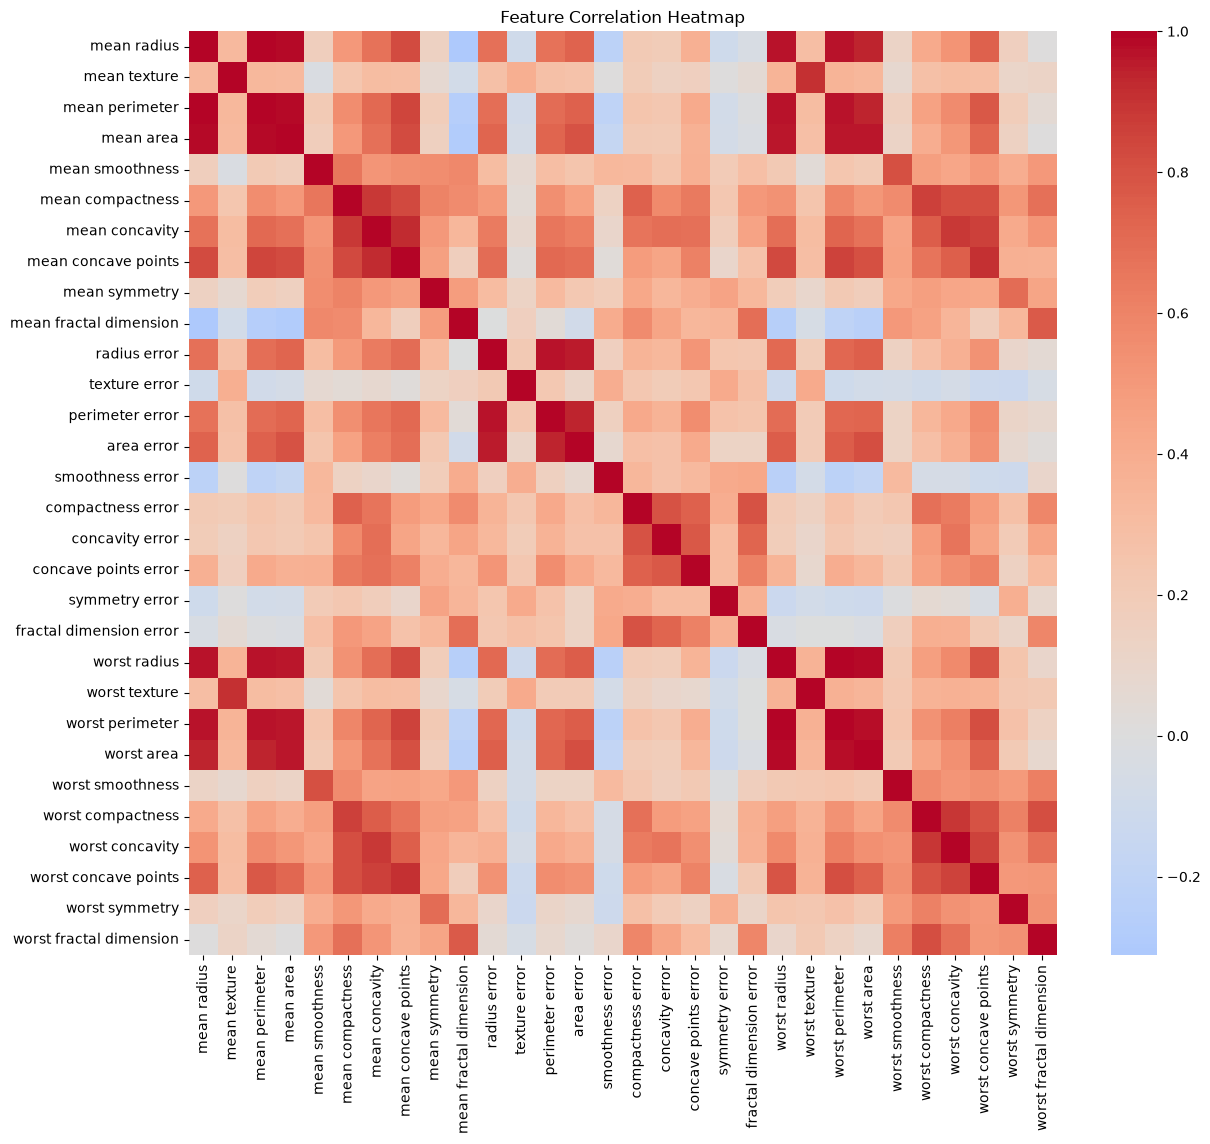

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.drop(columns=['target']).corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

In [4]:
X = df.drop(columns=['target'])
y = df['target']
# checking the raw variances
X.var().sort_values(ascending=False).head(10)

worst area         324167.385102
mean area          123843.554318
area error           2069.431583
worst perimeter      1129.130847
mean perimeter        590.440480
worst texture          37.776483
worst radius           23.360224
mean texture           18.498909
mean radius            12.418920
perimeter error         4.087896
dtype: float64

In [17]:
# using PCA to sort columns based on max variance captured
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

print("Original shape: ", X_scaled.shape)
print("PCA shape:", X_pca.shape)

Original shape:  (569, 30)
PCA shape: (569, 30)


In [18]:
explained_variance = pca.explained_variance_ratio_
print(explained_variance)

[4.42720256e-01 1.89711820e-01 9.39316326e-02 6.60213492e-02
 5.49576849e-02 4.02452204e-02 2.25073371e-02 1.58872380e-02
 1.38964937e-02 1.16897819e-02 9.79718988e-03 8.70537901e-03
 8.04524987e-03 5.23365745e-03 3.13783217e-03 2.66209337e-03
 1.97996793e-03 1.75395945e-03 1.64925306e-03 1.03864675e-03
 9.99096464e-04 9.14646751e-04 8.11361259e-04 6.01833567e-04
 5.16042379e-04 2.72587995e-04 2.30015463e-04 5.29779290e-05
 2.49601032e-05 4.43482743e-06]


In [19]:
for i, var in enumerate(explained_variance[:10]):
    print(f"PC{i+1}: {var:.4f} ({var*100:.2f}%)")

PC1: 0.4427 (44.27%)
PC2: 0.1897 (18.97%)
PC3: 0.0939 (9.39%)
PC4: 0.0660 (6.60%)
PC5: 0.0550 (5.50%)
PC6: 0.0402 (4.02%)
PC7: 0.0225 (2.25%)
PC8: 0.0159 (1.59%)
PC9: 0.0139 (1.39%)
PC10: 0.0117 (1.17%)


In [21]:
cumulative_variance = np.cumsum(explained_variance)

for i, cum_var in enumerate(cumulative_variance[:]):
    print(f"PC1 to PC{i + 1} : {cum_var*100:.2f} %")

PC1 to PC1 : 44.27 %
PC1 to PC2 : 63.24 %
PC1 to PC3 : 72.64 %
PC1 to PC4 : 79.24 %
PC1 to PC5 : 84.73 %
PC1 to PC6 : 88.76 %
PC1 to PC7 : 91.01 %
PC1 to PC8 : 92.60 %
PC1 to PC9 : 93.99 %
PC1 to PC10 : 95.16 %
PC1 to PC11 : 96.14 %
PC1 to PC12 : 97.01 %
PC1 to PC13 : 97.81 %
PC1 to PC14 : 98.34 %
PC1 to PC15 : 98.65 %
PC1 to PC16 : 98.92 %
PC1 to PC17 : 99.11 %
PC1 to PC18 : 99.29 %
PC1 to PC19 : 99.45 %
PC1 to PC20 : 99.56 %
PC1 to PC21 : 99.66 %
PC1 to PC22 : 99.75 %
PC1 to PC23 : 99.83 %
PC1 to PC24 : 99.89 %
PC1 to PC25 : 99.94 %
PC1 to PC26 : 99.97 %
PC1 to PC27 : 99.99 %
PC1 to PC28 : 100.00 %
PC1 to PC29 : 100.00 %
PC1 to PC30 : 100.00 %


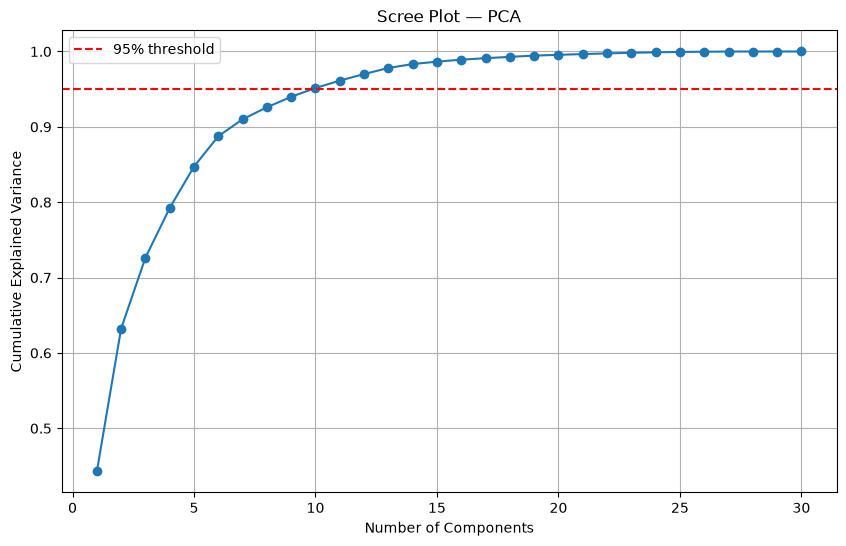

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, 31), cumulative_variance, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot — PCA')
plt.legend()
plt.grid(True)
plt.show()

In [26]:
pca_final = PCA(n_components=10)
X_pca_final = pca_final.fit_transform(X_scaled)

print("Reduced shape:", X_pca_final.shape)
print("Variance retained:", pca_final.explained_variance_ratio_.sum())

Reduced shape: (569, 10)
Variance retained: 0.9515688143366667


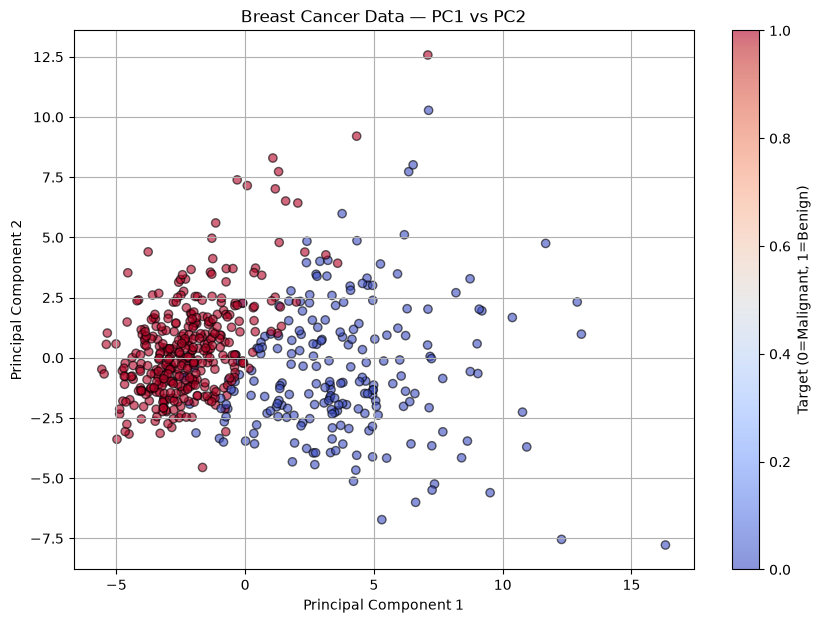

In [27]:
plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', alpha=0.6, edgecolors='k')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Breast Cancer Data — PC1 vs PC2')
plt.colorbar(label='Target (0=Malignant, 1=Benign)')
plt.grid(True)
plt.show()